In [2]:
import abagen
print("Environment OK")
print(abagen.__version__)

Environment OK
0.1.3


In [3]:
# Brain GWAS Enrichment
# Step 1 — Imports

import numpy as np
import pandas as pd
import abagen

print("Environment ready")

Environment ready


In [4]:
# Step 2 — Load Allen Human Brain Atlas data

data = abagen.fetch_microarray()

print("Data loaded")
print("Number of donors:", len(data))

Data loaded
Number of donors: 1


In [5]:
# Step 3 — Inspect downloaded dataset

print("Donors:", list(data.keys()))

donor_id = list(data.keys())[0]
donor_data = data[donor_id]

print("\nSelected donor:", donor_id)
print("\nAvailable files/data:")
for key, value in donor_data.items():
    print(f"{key}: {value}")

Donors: ['12876']

Selected donor: 12876

Available files/data:
microarray: C:\Users\LAPTOPS24\abagen-data\microarray\normalized_microarray_donor12876\MicroarrayExpression.csv
ontology: C:\Users\LAPTOPS24\abagen-data\microarray\normalized_microarray_donor12876\Ontology.csv
pacall: C:\Users\LAPTOPS24\abagen-data\microarray\normalized_microarray_donor12876\PACall.csv
probes: C:\Users\LAPTOPS24\abagen-data\microarray\normalized_microarray_donor12876\Probes.csv
annotation: C:\Users\LAPTOPS24\abagen-data\microarray\normalized_microarray_donor12876\SampleAnnot.csv


In [6]:
# Step 4 — Load core data files

expression = pd.read_csv(
    donor_data["microarray"],
    index_col=0
)

probes = pd.read_csv(
    donor_data["probes"]
)

annotation = pd.read_csv(
    donor_data["annotation"]
)

print("Expression:", expression.shape)
print("Probes:", probes.shape)
print("Annotation:", annotation.shape)

print("\nExpression index sample:")
print(expression.index[:5].tolist())

print("\nProbe columns:")
print(probes.columns.tolist())

print("\nAnnotation columns:")
print(annotation.columns.tolist())

Expression: (58691, 363)
Probes: (58692, 7)
Annotation: (363, 13)

Expression index sample:
[1058684, 1058683, 1058682, 1058681, 1058680]

Probe columns:
['probe_id', 'probe_name', 'gene_id', 'gene_symbol', 'gene_name', 'entrez_id', 'chromosome']

Annotation columns:
['structure_id', 'slab_num', 'well_id', 'slab_type', 'structure_acronym', 'structure_name', 'polygon_id', 'mri_voxel_x', 'mri_voxel_y', 'mri_voxel_z', 'mni_x', 'mni_y', 'mni_z']


In [7]:
# Step 5 — Verify probe alignment

expression_probe_ids = pd.Index(expression.index.astype(str))
annotation_probe_ids = pd.Index(probes["probe_id"].astype(str))

common = expression_probe_ids.intersection(annotation_probe_ids)

print("Expression probes:", len(expression_probe_ids))
print("Annotated probes:", len(annotation_probe_ids))
print("Common probes:", len(common))
print("Expression-only probes:", len(expression_probe_ids.difference(annotation_probe_ids)))
print("Annotation-only probes:", len(annotation_probe_ids.difference(expression_probe_ids)))

print("\nDuplicate probe IDs in annotation:",
      probes["probe_id"].astype(str).duplicated().sum())

Expression probes: 58691
Annotated probes: 58692
Common probes: 58691
Expression-only probes: 0
Annotation-only probes: 1

Duplicate probe IDs in annotation: 0


In [8]:
# Step 6 — Create the aligned probe dataset

# Keep only probes that actually exist in the expression matrix
probe_ids = expression.index.astype(str)

probes_aligned = probes[
    probes["probe_id"].astype(str).isin(probe_ids)
].copy()

# Preserve the expression matrix's exact probe order
probes_aligned["probe_id_str"] = probes_aligned["probe_id"].astype(str)

probes_aligned = (
    probes_aligned
    .set_index("probe_id_str")
    .loc[probe_ids]
)

# Verify alignment
assert len(probes_aligned) == len(expression)
assert probes_aligned.index.equals(probe_ids)

print("Aligned expression:", expression.shape)
print("Aligned probes:", probes_aligned.shape)
print("Probe order aligned:", probes_aligned.index.equals(probe_ids))

print("\nExample mapping:")
print(
    probes_aligned[
        ["probe_id", "gene_symbol", "gene_name"]
    ].head(10)
)

Aligned expression: (58691, 363)
Aligned probes: (58691, 7)
Probe order aligned: True

Example mapping:
         probe_id gene_symbol                                   gene_name
1058685                                                                  
1058684   1058684          C9                      complement component 9
1058683   1058683          C9                      complement component 9
1058682   1058682      MRPL49         mitochondrial ribosomal protein L49
1058681   1058681      MRPL49         mitochondrial ribosomal protein L49
1058680   1058680      MRPL49         mitochondrial ribosomal protein L49
1058679   1058679      ZNHIT2          zinc finger, HIT-type containing 2
1058678   1058678      ZNHIT2          zinc finger, HIT-type containing 2
1058677   1058677      MPPED2  metallophosphoesterase domain containing 2
1058676   1058676     C11orf9          chromosome 11 open reading frame 9
1058675   1058675     C11orf9          chromosome 11 open reading frame 9


In [9]:
# Step 7 — Check annotation completeness

print("Missing probe IDs:", probes_aligned["probe_id"].isna().sum())
print("Missing gene symbols:", probes_aligned["gene_symbol"].isna().sum())
print("Blank gene symbols:",
      (probes_aligned["gene_symbol"].astype(str).str.strip() == "").sum())

print("\nRows with missing/blank gene symbols:")
print(
    probes_aligned[
        probes_aligned["gene_symbol"].isna()
        | (probes_aligned["gene_symbol"].astype(str).str.strip() == "")
    ][["probe_id", "gene_symbol", "gene_name"]]
)

Missing probe IDs: 0
Missing gene symbols: 0
Blank gene symbols: 0

Rows with missing/blank gene symbols:
Empty DataFrame
Columns: [probe_id, gene_symbol, gene_name]
Index: []


In [10]:
# Step 8 — Collapse probe expression to gene-level expression

# Add gene symbols to the expression matrix
expression_with_genes = expression.copy()
expression_with_genes["gene_symbol"] = (
    probes_aligned["gene_symbol"].astype(str).str.upper().values
)

# Keep only actual expression columns
sample_columns = expression.columns.tolist()

# One value per gene: median across its probes
gene_expression = (
    expression_with_genes
    .groupby("gene_symbol")[sample_columns]
    .median()
)

print("Probe-level expression:", expression.shape)
print("Gene-level expression:", gene_expression.shape)

print("\nUnique genes:", gene_expression.shape[0])

print("\nExample:")
print(gene_expression.iloc[:5, :5])

Probe-level expression: (58691, 363)
Gene-level expression: (29131, 363)

Unique genes: 29131

Example:
             3.5010774998847847  4.15417262910917  4.10332400682848  \
gene_symbol                                                           
61E3.4                13.714128         13.719252         13.720934   
A1BG                   5.049439          5.173558          5.068065   
A1CF                   2.042317          1.973284          1.996434   
A26C1B                 6.168989          6.154843          6.158318   
A2BP1                 12.040668         12.183389         12.233327   

             3.9620342890083284  3.60717520237657  
gene_symbol                                        
61E3.4                13.872391         13.368193  
A1BG                   5.114931          4.945027  
A1CF                   1.981823          2.108420  
A26C1B                 6.334744          6.269155  
A2BP1                 12.369833         12.110327  


In [11]:
# Step 9 — Map samples to anatomical brain regions

sample_regions = annotation["structure_name"].astype(str).str.strip()

print("Samples:", len(sample_regions))
print("Unique brain regions:", sample_regions.nunique())
print("Missing region labels:", sample_regions.isna().sum())

print("\nSamples per region:")
print(sample_regions.value_counts().describe())

print("\nFirst 10 sample → region mappings:")
print(
    pd.DataFrame({
        "sample": annotation.index[:10],
        "region": sample_regions.iloc[:10].values
    })
)

Samples: 363
Unique brain regions: 158
Missing region labels: 0

Samples per region:
count    158.000000
mean       2.297468
std        1.342635
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       10.000000
Name: count, dtype: float64

First 10 sample → region mappings:
   sample                                             region
0       0  middle temporal gyrus, left, inferior bank of ...
1       1         inferior temporal gyrus, left, bank of mts
2       2     inferior temporal gyrus, left, bank of the its
3       3  middle temporal gyrus, left, superior bank of ...
4       4  superior temporal gyrus, left, lateral bank of...
5       5  middle temporal gyrus, left, inferior bank of ...
6       6                           short insular gyri, left
7       7                            long insular gyri, left
8       8                                planum polare, left
9       9  superior temporal gyrus, left, lateral bank of...


In [12]:
# Step 10 — Aggregate gene expression by brain region

# Transpose so samples are rows and genes are columns
gene_expression_by_sample = gene_expression.T.copy()

# Attach each sample's anatomical region
gene_expression_by_sample["region"] = sample_regions.values

# Average samples belonging to the same anatomical region
gene_expression_by_region = (
    gene_expression_by_sample
    .groupby("region", sort=True)
    .mean(numeric_only=True)
)

print("Gene × sample:", gene_expression.shape)
print("Gene × region:", gene_expression_by_region.T.shape)

print("\nNumber of regions:", len(gene_expression_by_region))
print("Number of genes:", gene_expression_by_region.shape[1])

print("\nMissing values:", gene_expression_by_region.isna().sum().sum())

print("\nExample:")
print(gene_expression_by_region.iloc[:3, :5])

Gene × sample: (29131, 363)
Gene × region: (29131, 158)

Number of regions: 158
Number of genes: 29131

Missing values: 0

Example:
gene_symbol         61E3.4      A1BG      A1CF    A26C1B      A2BP1
region                                                             
CA1 field, left  13.520663  5.527404  2.158168  5.780568  12.620117
CA2 field, left  14.008848  4.409110  2.014400  5.866712  13.292662
CA3 field, left  14.241345  5.103570  2.625283  5.990332  13.741444


In [13]:
# Step 11 — Define disease-associated gene sets

disease_genes = {
    "Parkinson's": [
        "SNCA", "LRRK2", "GBA", "PARK7", "PINK1",
        "PARK2", "MAPT", "APOE", "BST1", "GAK"
    ],
    
    "Alzheimer's": [
        "APOE", "PICALM", "CLU", "CR1", "ABCA7",
        "MS4A6A", "CD33", "EPHA1", "BIN1", "INPP5D"
    ],
    
    "Huntington's": [
        "HTT"
    ]
}

# Normalize gene names
disease_genes = {
    disease: sorted(set(g.upper() for g in genes))
    for disease, genes in disease_genes.items()
}

# Check which genes are actually present in the Allen dataset
available_genes = set(gene_expression_by_region.columns)

for disease, genes in disease_genes.items():
    matched = sorted(set(genes) & available_genes)
    missing = sorted(set(genes) - available_genes)

    print(f"\n{disease}")
    print("Requested:", len(genes))
    print("Matched:", len(matched))
    print("Missing:", len(missing))
    print("Matched genes:", matched)
    if missing:
        print("Missing genes:", missing)


Parkinson's
Requested: 10
Matched: 10
Missing: 0
Matched genes: ['APOE', 'BST1', 'GAK', 'GBA', 'LRRK2', 'MAPT', 'PARK2', 'PARK7', 'PINK1', 'SNCA']

Alzheimer's
Requested: 10
Matched: 10
Missing: 0
Matched genes: ['ABCA7', 'APOE', 'BIN1', 'CD33', 'CLU', 'CR1', 'EPHA1', 'INPP5D', 'MS4A6A', 'PICALM']

Huntington's
Requested: 1
Matched: 1
Missing: 0
Matched genes: ['HTT']


In [14]:
# Step 12 — Calculate observed disease-associated expression scores

observed_scores = {}

for disease, genes in disease_genes.items():
    matched_genes = sorted(set(genes) & available_genes)

    # One gene = one contribution
    disease_expression = gene_expression_by_region[matched_genes]

    # Mean expression across disease-associated genes
    regional_score = disease_expression.mean(axis=1)

    observed_scores[disease] = regional_score

observed_scores = pd.DataFrame(observed_scores)

print("Observed score matrix:", observed_scores.shape)

print("\nScore summary:")
print(observed_scores.describe())

print("\nTop regions by disease score:")
for disease in observed_scores.columns:
    print(f"\n{disease}")
    print(
        observed_scores[disease]
        .sort_values(ascending=False)
        .head(10)
    )

Observed score matrix: (158, 3)

Score summary:
       Parkinson's  Alzheimer's  Huntington's
count   158.000000   158.000000    158.000000
mean      8.160605     6.335758      7.946731
std       0.369292     0.297824      0.473673
min       6.968592     5.433249      6.124332
25%       7.901941     6.155193      7.715729
50%       8.219523     6.261357      8.005561
75%       8.404780     6.456468      8.267845
max       9.108526     7.419622      9.131505

Top regions by disease score:

Parkinson's
region
caudal group of intralaminar nuclei, left                9.108526
globus pallidus, external segment, left                  8.834607
bed  nucleus of stria terminalis, left                   8.833579
precentral gyrus, left, bank of the precentral sulcus    8.790524
substantia nigra, pars compacta, left                    8.727660
substantia nigra, pars reticulata, left                  8.706376
inferior rostral gyrus, left                             8.686004
supramarginal gyrus, left

In [15]:
# Step 13 — Standardize regional disease scores

from scipy.stats import zscore

observed_z = observed_scores.apply(zscore)

print("Standardized score matrix:", observed_z.shape)

print("\nStandardized score summary:")
print(observed_z.describe())

print("\nTop 10 relatively enriched regions:")
for disease in observed_z.columns:
    print(f"\n{disease}")
    print(
        observed_z[disease]
        .sort_values(ascending=False)
        .head(10)
    )

Standardized score matrix: (158, 3)

Standardized score summary:
        Parkinson's   Alzheimer's  Huntington's
count  1.580000e+02  1.580000e+02  1.580000e+02
mean   4.958059e-15 -1.135519e-15  1.023092e-15
std    1.003180e+00  1.003180e+00  1.003180e+00
min   -3.238097e+00 -3.039977e+00 -3.859611e+00
25%   -7.026601e-01 -6.082070e-01 -4.892335e-01
50%    1.600516e-01 -2.506081e-01  1.245940e-01
75%    6.633008e-01  4.065972e-01  6.800783e-01
max    2.575023e+00  3.650849e+00  2.509201e+00

Top 10 relatively enriched regions:

Parkinson's
region
caudal group of intralaminar nuclei, left                2.575023
globus pallidus, external segment, left                  1.830923
bed  nucleus of stria terminalis, left                   1.828130
precentral gyrus, left, bank of the precentral sulcus    1.711171
substantia nigra, pars compacta, left                    1.540403
substantia nigra, pars reticulata, left                  1.482583
inferior rostral gyrus, left                      

In [16]:
# Step 14 — Prepare gene-level permutation testing

RANDOM_SEED = 42
N_PERMUTATIONS = 5000

rng = np.random.default_rng(RANDOM_SEED)

all_genes = np.array(gene_expression_by_region.columns)

print("Total available genes:", len(all_genes))
print("Permutations:", N_PERMUTATIONS)
print("Random seed:", RANDOM_SEED)

for disease, genes in disease_genes.items():
    matched = np.array(sorted(set(genes) & available_genes))
    print(f"{disease}: {len(matched)} observed genes")

Total available genes: 29131
Permutations: 5000
Random seed: 42
Parkinson's: 10 observed genes
Alzheimer's: 10 observed genes
Huntington's: 1 observed genes


In [17]:
# Step 15 — Gene-level permutation test

from scipy.stats import false_discovery_control

permutation_results = {}

for disease, genes in disease_genes.items():
    matched_genes = np.array(sorted(set(genes) & available_genes))
    n_genes = len(matched_genes)

    observed = observed_scores[disease].values

    null_scores = np.empty((N_PERMUTATIONS, len(gene_expression_by_region)))

    for i in range(N_PERMUTATIONS):
        random_genes = rng.choice(
            all_genes,
            size=n_genes,
            replace=False
        )

        null_scores[i] = (
            gene_expression_by_region[random_genes]
            .mean(axis=1)
            .values
        )

    # Empirical one-sided p-value:
    # how often was a random gene set at least as high as observed?
    p_values = (
        1 + np.sum(null_scores >= observed[None, :], axis=0)
    ) / (N_PERMUTATIONS + 1)

    permutation_results[disease] = {
        "observed": observed,
        "null_scores": null_scores,
        "p_values": p_values
    }

    print(
        f"{disease}: completed "
        f"{N_PERMUTATIONS:,} permutations"
    )

print("\nPermutation testing complete.")

Parkinson's: completed 5,000 permutations
Alzheimer's: completed 5,000 permutations
Huntington's: completed 5,000 permutations

Permutation testing complete.


In [18]:
# Step 16 — FDR correction and significance

p_value_table = pd.DataFrame(
    {
        disease: results["p_values"]
        for disease, results in permutation_results.items()
    },
    index=gene_expression_by_region.index
)

# Benjamini-Hochberg FDR correction separately for each disease
fdr_table = pd.DataFrame(
    {
        disease: false_discovery_control(p_value_table[disease].values)
        for disease in p_value_table.columns
    },
    index=p_value_table.index
)

significant_table = fdr_table < 0.05

print("P-value range:")
print(p_value_table.agg(["min", "max"]))

print("\nNumber of FDR-significant regions:")
print(significant_table.sum())

print("\nMinimum FDR:")
print(fdr_table.min())

P-value range:
     Parkinson's  Alzheimer's  Huntington's
min     0.000400     0.013597      0.088382
max     0.015797     0.305139      0.280144

Number of FDR-significant regions:
Parkinson's     158
Alzheimer's       0
Huntington's      0
dtype: int64

Minimum FDR:
Parkinson's     0.001109
Alzheimer's     0.113922
Huntington's    0.209395
dtype: float64


In [19]:
# Step 17 — Effect sizes relative to the permutation null

effect_size_table = pd.DataFrame(index=gene_expression_by_region.index)

for disease, results in permutation_results.items():
    observed = results["observed"]
    null_scores = results["null_scores"]

    null_mean = null_scores.mean(axis=0)
    null_std = null_scores.std(axis=0, ddof=1)

    effect_size_table[disease] = (
        (observed - null_mean) / null_std
    )

print("Effect-size summary:")
print(effect_size_table.describe().round(3))

print("\nTop Parkinson's regions by effect size:")
print(
    effect_size_table["Parkinson's"]
    .sort_values(ascending=False)
    .head(10)
)

Effect-size summary:
       Parkinson's  Alzheimer's  Huntington's
count      158.000      158.000       158.000
mean         3.560        1.549         1.090
std          0.326        0.281         0.152
min          2.229        0.495         0.495
25%          3.375        1.355         1.027
50%          3.645        1.501         1.115
75%          3.786        1.697         1.184
max          4.160        2.345         1.471

Top Parkinson's regions by effect size:
region
substantia nigra, pars compacta, left                    4.160441
temporal pole, left, superior aspect                     4.143298
long insular gyri, left                                  4.113884
planum polare, left                                      4.036705
fusiform gyrus, left, bank of the its                    4.007304
fusiform gyrus, left, bank of cos                        4.004502
precentral gyrus, left, bank of the precentral sulcus    3.989866
gyrus rectus, left                                     

In [23]:
# Step 18 — Gene-wise regional expression normalization

gene_expression_z = pd.DataFrame(
    zscore(
        gene_expression_by_region.values,
        axis=0
    ),
    index=gene_expression_by_region.index,
    columns=gene_expression_by_region.columns
)

print("Gene-wise normalized expression:")
print("Shape:", gene_expression_z.shape)

print("\nExample gene:")
example_gene = "SNCA"

if example_gene in gene_expression_z.columns:
    print(
        gene_expression_z[example_gene]
        .describe()
        .round(3)
    )

Gene-wise normalized expression:
Shape: (158, 29131)

Example gene:
count    158.000
mean      -0.000
std        1.003
min       -3.792
25%       -0.639
50%        0.276
75%        0.765
max        1.390
Name: SNCA, dtype: float64


In [24]:
# Step 19 — Disease regional specificity scores

normalized_scores = {}

for disease, genes in disease_genes.items():
    matched_genes = sorted(set(genes) & set(gene_expression_z.columns))

    disease_score = gene_expression_z[matched_genes].mean(axis=1)

    normalized_scores[disease] = disease_score

normalized_scores = pd.DataFrame(normalized_scores)

print("Normalized disease scores:")
print("Shape:", normalized_scores.shape)

print("\nSummary:")
print(normalized_scores.describe().round(3))

print("\nTop regions:")
for disease in normalized_scores.columns:
    print(f"\n{disease}")
    print(
        normalized_scores[disease]
        .sort_values(ascending=False)
        .head(5)
    )

Normalized disease scores:
Shape: (158, 3)

Summary:
       Parkinson's  Alzheimer's  Huntington's
count      158.000      158.000       158.000
mean         0.000        0.000         0.000
std          0.566        0.448         1.003
min         -1.860       -1.250        -3.860
25%         -0.347       -0.289        -0.489
50%          0.093       -0.120         0.125
75%          0.346        0.202         0.680
max          1.582        1.653         2.509

Top regions:

Parkinson's
region
caudal group of intralaminar nuclei, left                1.581888
globus pallidus, external segment, left                  1.102698
bed  nucleus of stria terminalis, left                   1.040362
precentral gyrus, left, bank of the precentral sulcus    1.009074
substantia nigra, pars reticulata, left                  0.826362
Name: Parkinson's, dtype: float64

Alzheimer's
region
globus pallidus, external segment, left      1.653286
caudal group of intralaminar nuclei, left    1.632095
corpus 

In [25]:
# Step 20 — Permutation test using regional specificity

normalized_permutation_results = {}

rng_normalized = np.random.default_rng(RANDOM_SEED)

all_genes = np.array(gene_expression_z.columns)

for disease, genes in disease_genes.items():

    matched_genes = np.array(
        sorted(set(genes) & set(gene_expression_z.columns))
    )

    n_genes = len(matched_genes)

    observed = normalized_scores[disease].values

    null_scores = np.empty(
        (N_PERMUTATIONS, len(gene_expression_z))
    )

    for i in range(N_PERMUTATIONS):

        random_genes = rng_normalized.choice(
            all_genes,
            size=n_genes,
            replace=False
        )

        null_scores[i] = (
            gene_expression_z[random_genes]
            .mean(axis=1)
            .values
        )

    p_values = (
        1 + np.sum(
            null_scores >= observed[None, :],
            axis=0
        )
    ) / (N_PERMUTATIONS + 1)

    normalized_permutation_results[disease] = {
        "observed": observed,
        "null_scores": null_scores,
        "p_values": p_values
    }

    print(
        f"{disease}: completed "
        f"{N_PERMUTATIONS:,} normalized permutations"
    )

print("\nNormalized permutation testing complete.")

Parkinson's: completed 5,000 normalized permutations
Alzheimer's: completed 5,000 normalized permutations
Huntington's: completed 5,000 normalized permutations

Normalized permutation testing complete.


In [26]:
# Step 21 — FDR correction for normalized analysis

normalized_p_values = pd.DataFrame(
    {
        disease: results["p_values"]
        for disease, results in normalized_permutation_results.items()
    },
    index=gene_expression_z.index
)

normalized_fdr = pd.DataFrame(
    {
        disease: false_discovery_control(
            normalized_p_values[disease].values
        )
        for disease in normalized_p_values.columns
    },
    index=normalized_p_values.index
)

normalized_significant = normalized_fdr < 0.05

print("Normalized p-value range:")
print(normalized_p_values.agg(["min", "max"]).round(4))

print("\nNumber of FDR-significant regions:")
print(normalized_significant.sum())

print("\nMinimum FDR:")
print(normalized_fdr.min().round(4))

Normalized p-value range:
     Parkinson's  Alzheimer's  Huntington's
min       0.0008       0.0028        0.0096
max       1.0000       0.9968        0.9912

Number of FDR-significant regions:
Parkinson's     0
Alzheimer's     0
Huntington's    0
dtype: int64

Minimum FDR:
Parkinson's     0.0632
Alzheimer's     0.2422
Huntington's    0.6082
dtype: float64


In [27]:
# Step 22 — Compare disease-gene expression to the full gene background

gene_global_mean = gene_expression_by_region.mean(axis=0)

background_summary = pd.DataFrame(index=disease_genes.keys())

for disease, genes in disease_genes.items():
    matched = [
        gene for gene in genes
        if gene in gene_global_mean.index
    ]

    background_summary.loc[disease, "Disease gene count"] = len(matched)
    background_summary.loc[disease, "Mean expression"] = (
        gene_global_mean[matched].mean()
    )
    background_summary.loc[disease, "Median expression"] = (
        gene_global_mean[matched].median()
    )

background_summary["All genes mean"] = gene_global_mean.mean()
background_summary["All genes median"] = gene_global_mean.median()

print(background_summary.round(3))

              Disease gene count  Mean expression  Median expression  \
Parkinson's                 10.0            8.161              8.682   
Alzheimer's                 10.0            6.336              5.578   
Huntington's                 1.0            7.947              7.947   

              All genes mean  All genes median  
Parkinson's            5.035             4.799  
Alzheimer's            5.035             4.799  
Huntington's           5.035             4.799  


In [28]:
# Step 23 — Create expression-matched gene bins

gene_global_mean = gene_expression_by_region.mean(axis=0)

# Divide genes into 20 bins based on their global expression level
expression_bins = pd.qcut(
    gene_global_mean,
    q=20,
    labels=False,
    duplicates="drop"
)

gene_bin_table = pd.DataFrame({
    "global_mean_expression": gene_global_mean,
    "expression_bin": expression_bins
})

print("Number of expression bins:", gene_bin_table["expression_bin"].nunique())

print("\nGenes per bin:")
print(
    gene_bin_table["expression_bin"]
    .value_counts()
    .sort_index()
)

print("\nDisease gene bins:")

for disease, genes in disease_genes.items():
    matched = [
        gene for gene in genes
        if gene in gene_bin_table.index
    ]

    print(f"\n{disease}")

    for gene in matched:
        print(
            f"  {gene}: "
            f"expression={gene_bin_table.loc[gene, 'global_mean_expression']:.3f}, "
            f"bin={int(gene_bin_table.loc[gene, 'expression_bin'])}"
        )

Number of expression bins: 20

Genes per bin:
expression_bin
0     1457
1     1457
2     1456
3     1457
4     1456
5     1457
6     1456
7     1457
8     1456
9     1457
10    1456
11    1457
12    1456
13    1457
14    1456
15    1457
16    1456
17    1457
18    1456
19    1457
Name: count, dtype: int64

Disease gene bins:

Parkinson's
  APOE: expression=10.478, bin=19
  BST1: expression=3.369, bin=6
  GAK: expression=8.118, bin=17
  GBA: expression=7.031, bin=15
  LRRK2: expression=6.365, bin=13
  MAPT: expression=9.246, bin=18
  PARK2: expression=3.331, bin=6
  PARK7: expression=11.806, bin=19
  PINK1: expression=10.998, bin=19
  SNCA: expression=10.865, bin=19

Alzheimer's
  ABCA7: expression=4.680, bin=9
  APOE: expression=10.478, bin=19
  BIN1: expression=10.544, bin=19
  CD33: expression=3.227, bin=6
  CLU: expression=12.510, bin=19
  CR1: expression=2.012, bin=2
  EPHA1: expression=3.144, bin=6
  INPP5D: expression=6.477, bin=14
  MS4A6A: expression=2.703, bin=5
  PICALM: expr

In [30]:
# Step 24 — Expression-matched permutation test (optimized)

matched_permutation_results = {}

rng_matched = np.random.default_rng(RANDOM_SEED)

# Precompute genes available in each expression bin
genes_by_bin = {
    int(bin_id): gene_bin_table.index[
        gene_bin_table["expression_bin"] == bin_id
    ].to_numpy()
    for bin_id in gene_bin_table["expression_bin"].dropna().unique()
}

for disease, genes in disease_genes.items():

    matched_genes = np.array(
        sorted(set(genes) & set(gene_expression_z.columns))
    )

    disease_bins = (
        gene_bin_table.loc[matched_genes, "expression_bin"]
        .astype(int)
        .to_numpy()
    )

    observed = normalized_scores[disease].to_numpy()

    null_scores = np.empty(
        (N_PERMUTATIONS, len(gene_expression_z))
    )

    # Exclude the actual disease genes from the candidate pool
    disease_gene_set = set(matched_genes)

    candidate_by_bin = {}

    for bin_id in np.unique(disease_bins):
        candidate_by_bin[bin_id] = np.array([
            gene
            for gene in genes_by_bin[bin_id]
            if gene not in disease_gene_set
        ])

    # Generate matched random gene sets
    for i in range(N_PERMUTATIONS):

        random_genes = []

        for bin_id in disease_bins:
            candidates = candidate_by_bin[bin_id]

            random_gene = rng_matched.choice(candidates)
            random_genes.append(random_gene)

        null_scores[i] = (
            gene_expression_z[random_genes]
            .mean(axis=1)
            .to_numpy()
        )

    p_values = (
        1 + np.sum(
            null_scores >= observed[None, :],
            axis=0
        )
    ) / (N_PERMUTATIONS + 1)

    matched_permutation_results[disease] = {
        "observed": observed,
        "null_scores": null_scores,
        "p_values": p_values
    }

    print(
        f"{disease}: completed "
        f"{N_PERMUTATIONS:,} matched permutations"
    )

print("\nExpression-matched permutation testing complete.")

Parkinson's: completed 5,000 matched permutations
Alzheimer's: completed 5,000 matched permutations
Huntington's: completed 5,000 matched permutations

Expression-matched permutation testing complete.


In [31]:
# Step 25 — Expression-matched FDR correction

matched_p_values = pd.DataFrame(
    {
        disease: results["p_values"]
        for disease, results in matched_permutation_results.items()
    },
    index=gene_expression_z.index
)

matched_fdr = pd.DataFrame(
    {
        disease: false_discovery_control(
            matched_p_values[disease].values
        )
        for disease in matched_p_values.columns
    },
    index=matched_p_values.index
)

matched_significant = matched_fdr < 0.05

print("Expression-matched p-value range:")
print(matched_p_values.agg(["min", "max"]).T)

print("\nNumber of FDR-significant regions:")
print(matched_significant.sum())

print("\nMinimum FDR:")
print(matched_fdr.min())

Expression-matched p-value range:
                   min       max
Parkinson's   0.000200  0.999200
Alzheimer's   0.002200  0.995201
Huntington's  0.006399  0.988402

Number of FDR-significant regions:
Parkinson's     1
Alzheimer's     0
Huntington's    0
dtype: int64

Minimum FDR:
Parkinson's     0.031594
Alzheimer's     0.189562
Huntington's    0.537093
dtype: float64


In [32]:
# Step 26 — Final significant regions and effect sizes

matched_effect_sizes = {}

for disease, results in matched_permutation_results.items():
    observed = results["observed"]
    null_scores = results["null_scores"]

    null_mean = null_scores.mean(axis=0)
    null_std = null_scores.std(axis=0, ddof=1)

    matched_effect_sizes[disease] = (
        observed - null_mean
    ) / null_std

matched_effect_sizes = pd.DataFrame(
    matched_effect_sizes,
    index=gene_expression_z.index
)

for disease in matched_significant.columns:

    significant_regions = matched_fdr.index[
        matched_significant[disease]
    ]

    print(f"\n{disease}")
    
    if len(significant_regions) == 0:
        print("No FDR-significant regions.")
    else:
        result = pd.DataFrame({
            "FDR": matched_fdr.loc[significant_regions, disease],
            "Effect_size": matched_effect_sizes.loc[
                significant_regions, disease
            ],
            "Normalized_score": normalized_scores.loc[
                significant_regions, disease
            ]
        }).sort_values("FDR")

        print(result)


Parkinson's
                              FDR  Effect_size  Normalized_score
region                                                          
long insular gyri, left  0.031594     3.608248           0.65924

Alzheimer's
No FDR-significant regions.

Huntington's
No FDR-significant regions.


In [33]:
# Step 27 — Build real MNI coordinates for brain regions

region_coordinates = (
    annotation
    .groupby("structure_name")[["mni_x", "mni_y", "mni_z"]]
    .mean()
)

# Keep the exact region ordering used in our analysis
region_coordinates = region_coordinates.loc[
    gene_expression_by_region.index
]

print("Region coordinate table:", region_coordinates.shape)

print("\nMissing coordinates:")
print(region_coordinates.isna().sum())

print("\nCoordinate range:")
print(region_coordinates.agg(["min", "max"]))

print("\nExample regions:")
print(region_coordinates.head())

Region coordinate table: (158, 3)

Missing coordinates:
mni_x    0
mni_y    0
mni_z    0
dtype: int64

Coordinate range:
         mni_x  mni_y  mni_z
min -66.333333  -86.5  -61.0
max   1.000000   47.0   72.0

Example regions:
                                  mni_x  mni_y  mni_z
region                                               
CA1 field, left                   -32.0 -18.25  -16.5
CA2 field, left                   -30.5 -27.50   -2.0
CA3 field, left                   -30.5 -27.50   -4.5
CA4 field, left                   -33.0 -35.00    2.0
Crus I, left, lateral hemisphere  -19.5 -82.00  -25.5


ModuleNotFoundError: No module named 'matplotlib'

In [35]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached kiwisolver-1.5.1-cp310-cp310-win_amd64.whl (70 kB)
  Using cached fonttools-4.65.0-cp310-cp310-win_amd64.whl (1.6 MB)
  Using cached pillow-12.3.0-cp310-cp310-win_amd64.whl (7.2 MB)
  Using cached pyparsing-3.3.3-py3-none-any.whl (126 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)


You should consider upgrading via the 'C:\Users\LAPTOPS24\Documents\HRISHITA\CODING\projs\brain\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


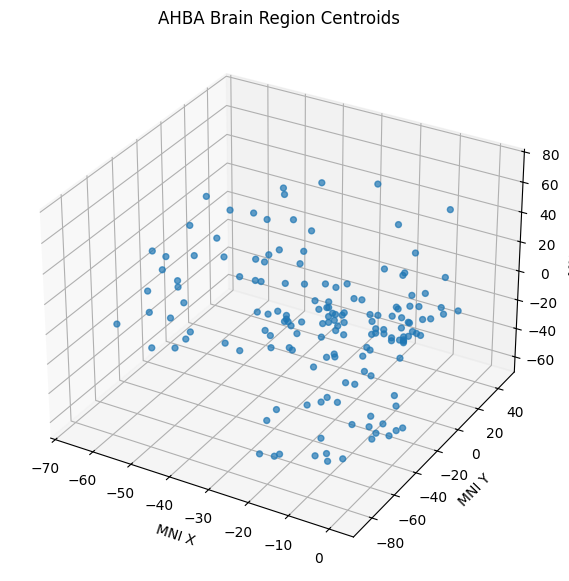

In [36]:
# Step 28 — Inspect the real brain-region spatial distribution

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    region_coordinates["mni_x"],
    region_coordinates["mni_y"],
    region_coordinates["mni_z"],
    s=18,
    alpha=0.7
)

ax.set_xlabel("MNI X")
ax.set_ylabel("MNI Y")
ax.set_zlabel("MNI Z")
ax.set_title("AHBA Brain Region Centroids")

plt.show()


In [37]:
# Step 29 — Check visualization dependencies

import importlib.util

packages = ["nibabel", "nilearn", "plotly", "trimesh"]

for package in packages:
    installed = importlib.util.find_spec(package) is not None
    print(f"{package}: {'installed' if installed else 'NOT installed'}")

nibabel: installed
nilearn: NOT installed
plotly: NOT installed
trimesh: NOT installed


In [38]:
# Step 30 — Check available neuroimaging resources

import nibabel as nib

print("Nibabel version:", nib.__version__)

try:
    from nilearn import datasets
    print("Nilearn available")
except ImportError:
    print("Nilearn not installed — we'll use another route.")

Nibabel version: 5.4.2
Nilearn not installed — we'll use another route.


In [39]:
%pip install nilearn plotly

^C
Note: you may need to restart the kernel to use updated packages.


In [40]:
!pip install nilearn plotly

  Using cached nilearn-0.14.1-py3-none-any.whl (11.5 MB)


You should consider upgrading via the 'C:\Users\LAPTOPS24\Documents\HRISHITA\CODING\projs\brain\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)


You should consider upgrading via the 'c:\Users\LAPTOPS24\Documents\HRISHITA\CODING\projs\brain\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [41]:
# Step 31 — Load the MNI gray-matter brain template

from nilearn import datasets

gm_template = datasets.load_mni152_gm_template(resolution=2)

print("Template loaded")
print("Shape:", gm_template.shape)
print("Voxel size:", gm_template.header.get_zooms()[:3])
print("Affine:")
print(gm_template.affine)

Template loaded
Shape: (99, 117, 95)
Voxel size: (np.float32(2.0), np.float32(2.0), np.float32(2.0))
Affine:
[[   2.    0.    0.  -98.]
 [   0.    2.    0. -134.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]


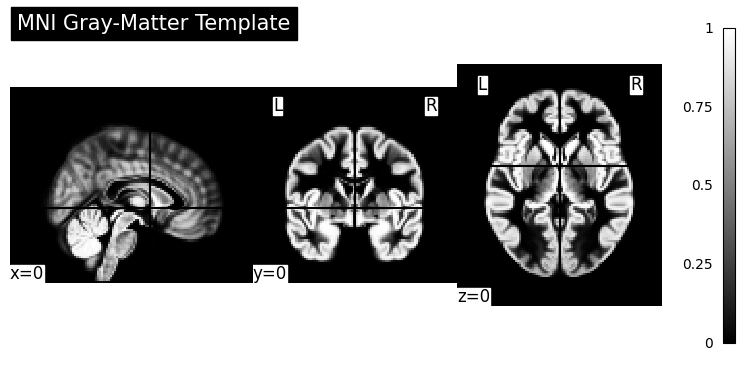

In [43]:
# Step 32 — Inspect the anatomical brain template

from nilearn import plotting
import matplotlib.pyplot as plt

plotting.plot_img(
    gm_template,
    display_mode="ortho",
    cut_coords=(0, 0, 0),
    title="MNI Gray-Matter Template"
)

plt.show()

In [44]:
# Step 33 — Prepare the brain volume for 3D surface extraction

import numpy as np
from scipy import ndimage

brain_data = gm_template.get_fdata()

# Keep the gray-matter region
brain_mask = brain_data > 0.15

# Remove tiny disconnected components
brain_mask = ndimage.binary_opening(brain_mask)
brain_mask = ndimage.binary_closing(brain_mask)

print("Brain volume shape:", brain_data.shape)
print("Brain voxels:", brain_mask.sum())
print("Brain coverage:", round(brain_mask.mean() * 100, 2), "%")

Brain volume shape: (99, 117, 95)
Brain voxels: 194945
Brain coverage: 17.72 %


scikit-image: installed


In [47]:
!pip install scikit-image

  Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)


You should consider upgrading via the 'C:\Users\LAPTOPS24\Documents\HRISHITA\CODING\projs\brain\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [49]:
# Step 34 — Check mesh extraction dependency

import importlib.util

print(
    "scikit-image:",
    "installed" if importlib.util.find_spec("skimage") else "NOT installed"
)

scikit-image: installed


In [50]:
# Step 35 — Extract the 3D brain surface

from skimage.measure import marching_cubes

verts, faces, normals, values = marching_cubes(
    brain_mask.astype(np.float32),
    level=0.5
)

# Convert voxel coordinates → MNI coordinates
affine = gm_template.affine

verts_h = np.c_[
    verts,
    np.ones(len(verts))
]

verts_mni = (affine @ verts_h.T).T[:, :3]

print("Surface extracted")
print("Vertices:", len(verts_mni))
print("Triangles:", len(faces))
print("MNI coordinate range:")
print(pd.DataFrame(
    verts_mni,
    columns=["mni_x", "mni_y", "mni_z"]
).agg(["min", "max"]))

Surface extracted
Vertices: 70030
Triangles: 140272
MNI coordinate range:
     mni_x  mni_y  mni_z
min  -73.0 -107.0  -71.0
max   73.0   75.0   83.0


In [51]:
# Step 36 — Create a lightweight interactive brain mesh

import plotly.graph_objects as go

# Downsample the surface for browser performance
# Keep every 4th triangle
face_step = 4
faces_light = faces[::face_step]

# Keep only vertices referenced by the reduced faces
used_vertices = np.unique(faces_light)

vertex_map = np.full(len(verts_mni), -1, dtype=int)
vertex_map[used_vertices] = np.arange(len(used_vertices))

faces_light = vertex_map[faces_light]
verts_light = verts_mni[used_vertices]

print("Lightweight mesh:")
print("Vertices:", len(verts_light))
print("Triangles:", len(faces_light))

Lightweight mesh:
Vertices: 62646
Triangles: 35068


In [52]:
# Step 37 — First interactive 3D brain

fig = go.Figure()

fig.add_trace(
    go.Mesh3d(
        x=verts_light[:, 0],
        y=verts_light[:, 1],
        z=verts_light[:, 2],
        i=faces_light[:, 0],
        j=faces_light[:, 1],
        k=faces_light[:, 2],
        opacity=0.22,
        color="lightgray",
        flatshading=False,
        hoverinfo="skip"
    )
)

fig.update_layout(
    title="Interactive MNI Brain",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode="data",
        bgcolor="white",
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=700
)

fig.show()

In [53]:
# Step 38 — Build final region-level visualization data

region_data = region_coordinates.copy()

for disease in disease_genes:
    region_data[f"{disease}_score"] = normalized_scores[disease]
    region_data[f"{disease}_p"] = matched_p_values[disease]
    region_data[f"{disease}_fdr"] = matched_fdr[disease]
    region_data[f"{disease}_effect"] = matched_effect_sizes[disease]

region_data["significant_parkinsons"] = (
    matched_fdr["Parkinson's"] < 0.05
)

print("Final region data:", region_data.shape)
print("\nColumns:")
print(region_data.columns.tolist())

print("\nParkinson's significant regions:")
print(
    region_data.loc[
        region_data["significant_parkinsons"],
        ["mni_x", "mni_y", "mni_z",
         "Parkinson's_score",
         "Parkinson's_fdr",
         "Parkinson's_effect"]
    ]
)

Final region data: (158, 16)

Columns:
['mni_x', 'mni_y', 'mni_z', "Parkinson's_score", "Parkinson's_p", "Parkinson's_fdr", "Parkinson's_effect", "Alzheimer's_score", "Alzheimer's_p", "Alzheimer's_fdr", "Alzheimer's_effect", "Huntington's_score", "Huntington's_p", "Huntington's_fdr", "Huntington's_effect", 'significant_parkinsons']

Parkinson's significant regions:
                         mni_x  mni_y  mni_z  Parkinson's_score  \
region                                                            
long insular gyri, left  -41.0  -14.0    4.0            0.65924   

                         Parkinson's_fdr  Parkinson's_effect  
region                                                        
long insular gyri, left         0.031594            3.608248  


In [54]:
# Step 39 — Prepare frontend-ready region data

region_data = region_data.reset_index()
region_data = region_data.rename(columns={"region": "region_name"})

# Add a simple disease key mapping for the frontend
disease_keys = {
    "Parkinson's": "parkinsons",
    "Alzheimer's": "alzheimers",
    "Huntington's": "huntingtons"
}

print("Frontend-ready region data:", region_data.shape)

print("\nFirst 5 regions:")
print(
    region_data[
        ["region_name", "mni_x", "mni_y", "mni_z"]
    ].head()
)

Frontend-ready region data: (158, 17)

First 5 regions:
                        region_name  mni_x  mni_y  mni_z
0                   CA1 field, left  -32.0 -18.25  -16.5
1                   CA2 field, left  -30.5 -27.50   -2.0
2                   CA3 field, left  -30.5 -27.50   -4.5
3                   CA4 field, left  -33.0 -35.00    2.0
4  Crus I, left, lateral hemisphere  -19.5 -82.00  -25.5


In [55]:
# Step 40 — Frontend configuration

disease_config = {
    "parkinsons": {
        "name": "Parkinson's",
        "short_name": "Parkinson's",
        "color": "#7CFF8A",
        "gene_count": len(disease_genes["Parkinson's"]),
        "significant_regions": int(
            (matched_fdr["Parkinson's"] < 0.05).sum()
        ),
    },
    "alzheimers": {
        "name": "Alzheimer's",
        "short_name": "Alzheimer's",
        "color": "#7CFF8A",
        "gene_count": len(disease_genes["Alzheimer's"]),
        "significant_regions": int(
            (matched_fdr["Alzheimer's"] < 0.05).sum()
        ),
    },
    "huntingtons": {
        "name": "Huntington's",
        "short_name": "Huntington's",
        "color": "#7CFF8A",
        "gene_count": len(disease_genes["Huntington's"]),
        "significant_regions": int(
            (matched_fdr["Huntington's"] < 0.05).sum()
        ),
    },
}

print("Frontend disease configuration:")
for key, config in disease_config.items():
    print(
        key,
        "→",
        config["gene_count"],
        "genes,",
        config["significant_regions"],
        "significant regions"
    )

Frontend disease configuration:
parkinsons → 10 genes, 1 significant regions
alzheimers → 10 genes, 0 significant regions
huntingtons → 1 genes, 0 significant regions


In [56]:
# Step 41 — Export analysis results for the web app

import json
from pathlib import Path

output_dir = Path("app_data")
output_dir.mkdir(exist_ok=True)

# Export region-level results
region_data.to_json(
    output_dir / "region_data.json",
    orient="records",
    indent=2
)

# Export disease configuration
with open(output_dir / "disease_config.json", "w") as f:
    json.dump(disease_config, f, indent=2)

print("Exported:")
print("-", output_dir / "region_data.json")
print("-", output_dir / "disease_config.json")

Exported:
- app_data\region_data.json
- app_data\disease_config.json


In [57]:
import streamlit
import plotly

print("Streamlit:", streamlit.__version__)
print("Plotly:", plotly.__version__)

ModuleNotFoundError: No module named 'streamlit'

In [58]:
!pip install streamlit

  Using cached streamlit-1.64.0-py3-none-any.whl (10.1 MB)
  Using cached pydeck-0.9.3-py2.py3-none-any.whl (11.4 MB)
  Using cached altair-6.2.2-py3-none-any.whl (797 kB)
  Using cached starlette-1.7.0-py3-none-any.whl (78 kB)
  Using cached protobuf-7.36.2-cp310-abi3-win_amd64.whl (456 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl (16 kB)
  Using cached httptools-0.8.0-cp310-cp310-win_amd64.whl (90 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl (79 kB)
  Using cached websockets-16.1.1-cp310-cp310-win_amd64.whl (180 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
  Using cached click-8.5.0-py3-none-any.whl (125 kB)
  Using cached pyarrow-25.0.1-cp310-cp310-win_amd64.whl (27.8 MB)
  Using cached python_multipart-0.0.32-py3-none-any.whl (30 kB)


You should consider upgrading via the 'C:\Users\LAPTOPS24\Documents\HRISHITA\CODING\projs\brain\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [64]:
# Step 42 — Create a smoother brain surface from the continuous GM template

from scipy.ndimage import gaussian_filter
from skimage.measure import marching_cubes

# Smooth the continuous gray-matter probability map
smoothed_brain = gaussian_filter(brain_data, sigma=1.5)

# Extract surface directly from the smoothed volume
verts, faces, normals, values = marching_cubes(
    smoothed_brain,
    level=0.15,
    step_size=1,
)

# Convert voxel coordinates → MNI coordinates
affine = gm_template.affine

verts_h = np.c_[verts, np.ones(len(verts))]
verts_mni = (affine @ verts_h.T).T[:, :3]

print("Brain mesh vertices:", len(verts_mni))
print("Brain mesh triangles:", len(faces))

Brain mesh vertices: 49432
Brain mesh triangles: 98800


In [65]:
# Step 42 — Export the brain mesh for the web app

mesh_output = output_dir / "brain_mesh.npz"

np.savez_compressed(
    mesh_output,
    vertices=verts_mni.astype(np.float32),
    faces=faces.astype(np.int32),
)

print("Brain mesh exported:")
print(mesh_output)

print("\nVertices:", len(verts_mni))
print("Triangles:", len(faces))

Brain mesh exported:
app_data\brain_mesh.npz

Vertices: 49432
Triangles: 98800
